In [2]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

from experiments.targets import Banana_t, MultivariateStudentT

from importlib import reload
import src.flows
reload(src.flows)
from src.flows import RealNVP
from src.train import train
from src.scp_core import SCP, uniform_sample_bright_side, rwm_bright_side

In [284]:
d = 50
df = 5
target = Banana_t(df=df, dim=d)
# target = MultivariateStudentT(df=df, dim=d)

key = jax.random.key(0)
exact_samples = target.sample(seed=key, n=2000)
# exact_samples = target.sample(seed=key, sample_shape=(2000,))

In [285]:
jnp.abs(exact_samples).max()

Array(82.60178, dtype=float32)

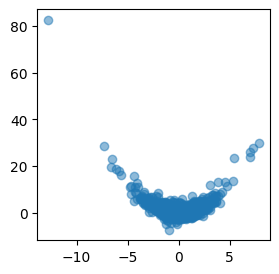

In [286]:
plt.figure(figsize=(3, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5)

In [287]:
# ref_dist = MultivariateStudentT(df=df, dim=d)
# key, subkey = jax.random.split(key)
latitude = 1.6
n_train = 5000
# ref_samples = ref_dist.sample(seed=jax.random.key(0), sample_shape=(n_train, ))

ref_samples = uniform_sample_bright_side(d, latitude, key=jax.random.key(0), n=n_train)
scp_model = SCP(d, latitude)

params_scp = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': jnp.log(jnp.sqrt(d)) * 0
}

ref_samples = scp_model.projection(params_scp, ref_samples)

In [288]:
jnp.abs(ref_samples).max()

Array(4.3047566, dtype=float32)

In [249]:
jnp.std(ref_samples[:, 0], 0)

Array(0.4128227, dtype=float32)

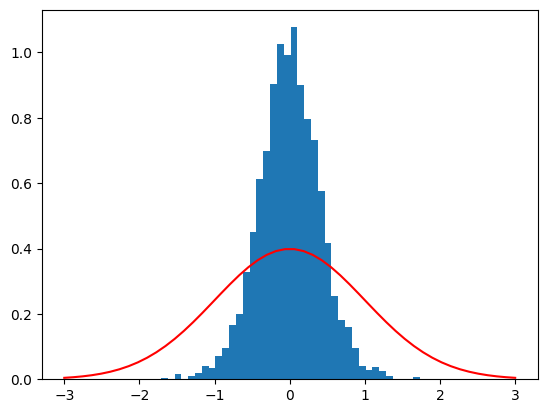

In [289]:
from scipy.stats import norm
# # plt.scatter(ref_samples[:, 0], ref_samples[:, 1], alpha=0.5, label='Reference')
plt.hist(ref_samples[abs(ref_samples[:, 0]) < 20, 0], 50, density=True)
plt.plot(jnp.linspace(-3, 3), norm.pdf(jnp.linspace(-3, 3), loc=0, scale=1), label='Normal', color='red')

In [290]:
model = RealNVP(dim=d, n_layers=4, hidden_dims=[d], init_scale=0.001)
params = model.init(jax.random.key(0), jnp.zeros((1, d)))

@jax.jit
def loss_fn(params):
    # return model.apply(params, ref_samples, target.log_prob, method=model.reverse_kl)
    X, log_det = model.apply(params, ref_samples, method=model.forward)
    X = jnp.clip(X, -1e4, 1e4)
    logp = jax.vmap(target.log_prob)(X)
    logp = jnp.where(jnp.abs(logp) < 1e10, logp, jnp.nan)
    return -jnp.nanmean(log_det + logp)

learning_rate = 1e-4
max_iter = 2000
params_nvp, losses_nvp = train(loss_fn, params, learning_rate=learning_rate, max_iter=max_iter)

Running for 2,000 iterations: 100%|██████████| 2000/2000 [00:16<00:00, 123.07it/s]


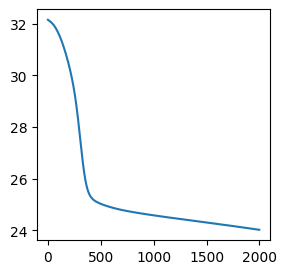

In [291]:
plt.figure(figsize=(3, 3))
plt.plot(losses_nvp)

In [292]:
transformed_samples = model.apply(params_nvp, ref_samples, method=model.forward)[0]

In [293]:
from scipy.stats import t
jnp.mean(transformed_samples[:, 0] <= t.ppf(0.99, df=df))

Array(0.99679995, dtype=float32)

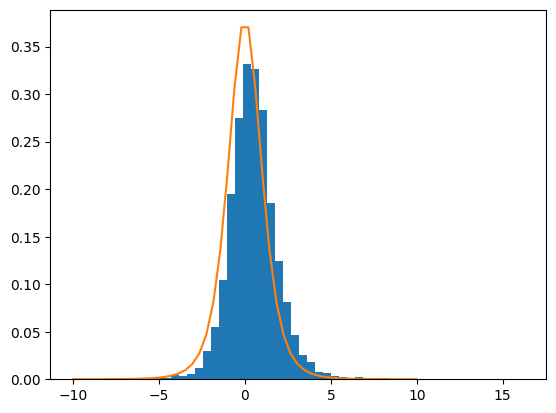

In [294]:
plt.hist(transformed_samples[abs(transformed_samples[:, 1]) < 20, 1], 50, density=True)
xx = jnp.linspace(-10, 10)
plt.plot(xx, t.pdf(xx, df=df))

In [ ]:
# key, subkey = jax.random.split(key)
# test_samples = ref_dist.sample(seed=subkey, sample_shape=(2000, ))
# transformed_samples, logdet = model.apply(params_nvp, test_samples, method=model.forward)

In [295]:
transformed_samples.shape

(5000, 50)

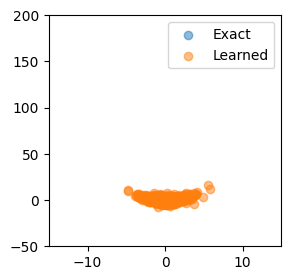

In [296]:
plt.figure(figsize=(3, 3))
plt.scatter(ref_samples[:, 0], ref_samples[:, 0]**2 * .5 + ref_samples[:, 1], alpha=.5, label='Exact')
plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], alpha=0.5, label='Learned')
plt.ylim(-50, 200)
plt.xlim(-15, 15)
plt.legend()

In [358]:
def logp_transformed_by_nvp(x):
    y, logdet = model.apply(params_nvp, x, method=model.forward)
    logp = target.log_prob(y)
    return logp + logdet

logp_sphere = scp_model.transform_target(logp_transformed_by_nvp, params_scp)
# logp_sphere = scp_model.transform_target(target.log_prob, params_scp)

nsample = 100_000
burnin = 500
x0 = uniform_sample_bright_side(d, latitude, jax.random.key(1), n=1)[0]
seed = 1
mcmc_samples_sphere, accepts = rwm_bright_side(logp_sphere, x0, latitude, key=jax.random.key(seed), nsample=nsample+burnin, stepsize=1)
print(accepts.mean())

0.4300398


In [359]:
transformed_mcmc_samples = scp_model.projection(params_scp, mcmc_samples_sphere[burnin:])
transformed_mcmc_samples = model.apply(params_nvp, transformed_mcmc_samples, method=model.forward)[0]

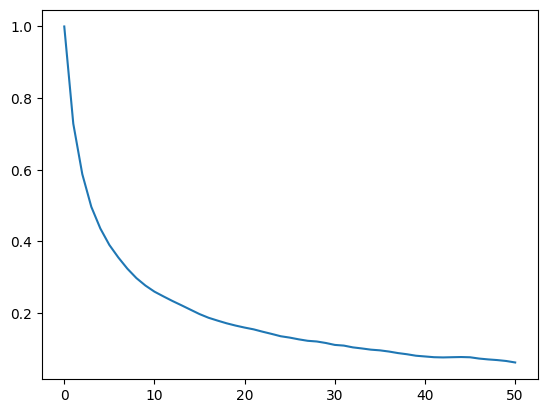

In [360]:
from statsmodels.tsa.stattools import acf
acf_vals = acf(transformed_mcmc_samples[:, 1], nlags=50, fft=True)  
plt.plot(acf_vals)

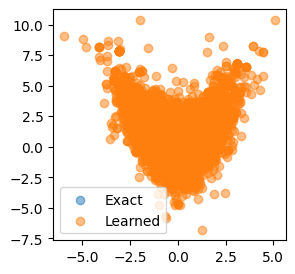

In [361]:
plt.figure(figsize=(3, 3))
plt.scatter(ref_samples[:, 0], ref_samples[:, 0]**2 * .5 + ref_samples[:, 1], alpha=.5, label='Exact')
plt.scatter(transformed_mcmc_samples[::10, 0], transformed_mcmc_samples[::10, 1], alpha=0.5, label='Learned')
# plt.ylim(-50, 200)
# plt.xlim(-15, 15)
plt.legend()

In [362]:
exact_samples = target.sample(seed=jax.random.key(0), n=100_000)

In [363]:
for a in [1, 2, 3, 4, 5]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 0] > a)), ', MCMC:', '{:.3f}'.format(jnp.mean(transformed_mcmc_samples[:, 0] > a)))

CDF at x = 1
exact: 0.183 , MCMC: 0.175
CDF at x = 2
exact: 0.050 , MCMC: 0.040
CDF at x = 3
exact: 0.015 , MCMC: 0.007
CDF at x = 4
exact: 0.005 , MCMC: 0.001
CDF at x = 5
exact: 0.002 , MCMC: 0.000


In [364]:
for a in [1, 3, 5, 8, 10, 20, 30, 40, 50]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 1] > a)), ', MCMC:', '{:.3f}'.format(jnp.mean(transformed_mcmc_samples[:, 1] > a)))

CDF at x = 1
exact: 0.352 , MCMC: 0.344
CDF at x = 3
exact: 0.087 , MCMC: 0.073
CDF at x = 5
exact: 0.033 , MCMC: 0.017
CDF at x = 8
exact: 0.013 , MCMC: 0.002
CDF at x = 10
exact: 0.008 , MCMC: 0.000
CDF at x = 20
exact: 0.002 , MCMC: 0.000
CDF at x = 30
exact: 0.001 , MCMC: 0.000
CDF at x = 40
exact: 0.000 , MCMC: 0.000
CDF at x = 50
exact: 0.000 , MCMC: 0.000


In [340]:
logq = ref_dist.log_prob(test_samples) - logdet
logp = target.log_prob(transformed_samples)
log_weights = logp - logq
ess = jnp.exp(logsumexp(log_weights) * 2 - logsumexp(log_weights * 2))
print(f"ESS: {ess:.2f}")

NameError: name 'ref_dist' is not defined

(-15.0, 15.0)

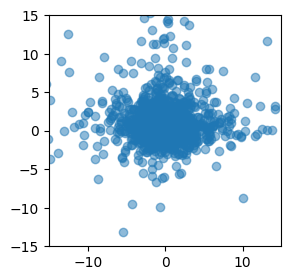

In [161]:
pullback_samples = model.apply(params_nvp, exact_samples, method=model.inverse)[0]
plt.figure(figsize=(3, 3))
plt.scatter(pullback_samples[:, 0], pullback_samples[:, 1], alpha=0.5)
plt.xlim(-15, 15)
plt.ylim(-15, 15)

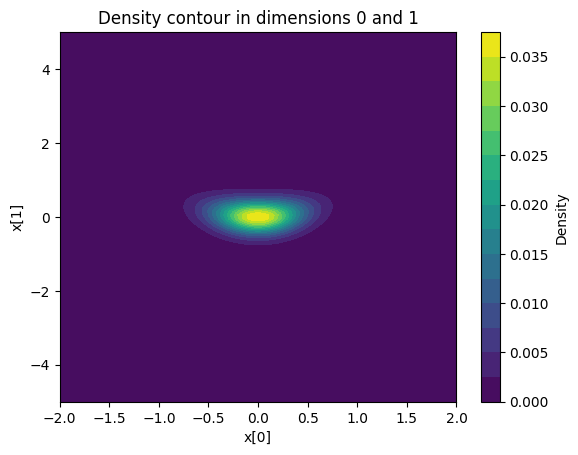

In [17]:
def plot_density_contour(logp, i, j, d, xlim=(-3, 3), ylim=(-3, 3), n_grid=100):
    x_vals = jnp.linspace(xlim[0], xlim[1], n_grid)
    y_vals = jnp.linspace(ylim[0], ylim[1], n_grid)
    X, Y = jnp.meshgrid(x_vals, y_vals, indexing='ij')
    points_2d = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

    def embed_to_d(x_ij):
        x = jnp.zeros(d)
        x = x.at[i].set(x_ij[0])
        x = x.at[j].set(x_ij[1])
        return x

    logp_vmapped = jax.vmap(lambda x_ij: logp(embed_to_d(x_ij)))
    Z = jnp.exp(logp_vmapped(points_2d)).reshape((n_grid, n_grid))

    plt.contourf(x_vals, y_vals, Z.T, levels=15, cmap='viridis')
    plt.xlabel(f"x[{i}]")
    plt.ylabel(f"x[{j}]")
    plt.colorbar(label="Density")
    plt.title(f"Density contour in dimensions {i} and {j}")

plot_density_contour(target.log_prob, 0, 1, d, xlim=(-2, 2), ylim=(-5, 5))

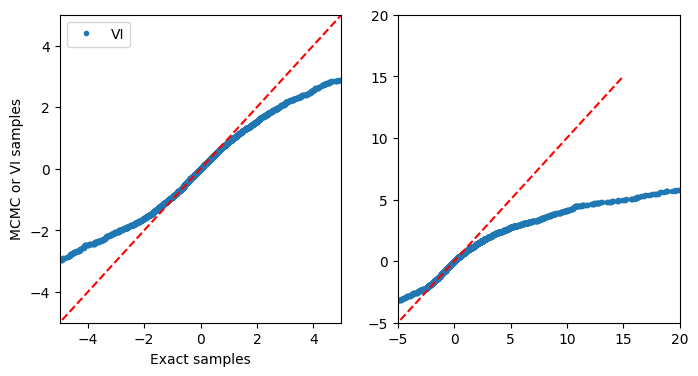

In [163]:
exact_samples = target.sample(seed=key, n=transformed_samples.shape[0])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 5)
ax[0].set_ylim(-5., 5)
ax[1].set_xlim(-5, 20)
ax[1].set_ylim(-5, 20)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

## Training SCP

In [20]:
latitude = 1.5
scp_model = SCP(d=d, latitude=latitude)

params_scp = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

seed = 0
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=n_train)

@jax.jit
def loss_fn(params):
    return scp_model.reverse_kl(params, target.log_prob, X)

opt_params, losses = train(loss_fn, params_scp, learning_rate=0.01, max_iter=1000)

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 1094.34it/s]


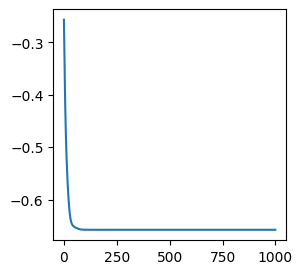

In [21]:
plt.figure(figsize=(3, 3))
plt.plot(losses)

In [23]:
transformed_samples = scp_model.projection(opt_params, X)

(-10.0, 50.0)

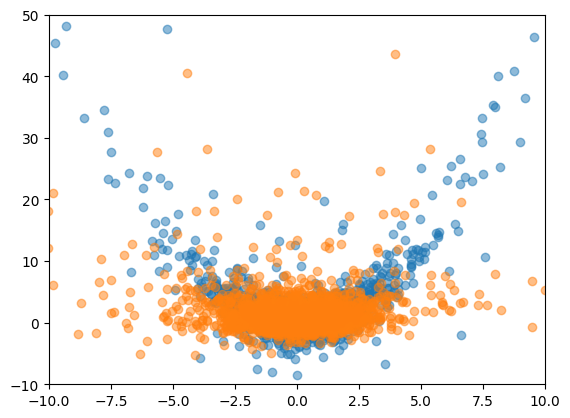

In [24]:
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5, label='Exact')
plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], alpha=0.5)
plt.xlim(-10, 10)
plt.ylim(-10, 50)

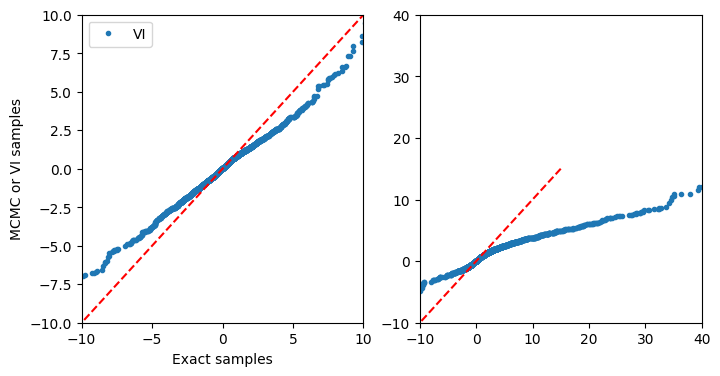

In [27]:
exact_samples = target.sample(seed=jax.random.key(1), n=transformed_samples.shape[0])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    vi_sorted = jnp.sort(transformed_samples[:, j])
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-10., 10)
ax[0].set_ylim(-10., 10)
ax[1].set_xlim(-10, 40)
ax[1].set_ylim(-10, 40)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

## Joint training

In [164]:
latitude = 1.7
scp_model = SCP(d=d, latitude=latitude)

params_scp = {
    'observer': jnp.zeros(d),
    'shift': jnp.zeros(d),
    'scale': 0.
}

nvp_model = RealNVP(dim=d, n_layers=4, hidden_dims=[d], init_scale=0.001)
params_nvp = nvp_model.init(jax.random.key(1), jnp.zeros((1, d)))

seed = 1
n_train = 5000
X = uniform_sample_bright_side(d, latitude, jax.random.key(seed), n=n_train)

params = {'scp': params_scp, 'nvp': params_nvp}


In [19]:
# Y = scp_model.projection(params_scp, X)
# Y = jnp.clip(Y, -1e4, 1e4)
# logdet_scp = jax.vmap(scp_model.log_jacobian, in_axes=(None, 0))(params_scp, Y)
# print(Y.max(), Y.min(), logdet_scp.max(), logdet_scp.min())

# Y, logdet_nvp = nvp_model.apply(params_nvp, Y, method=nvp_model.forward)
# print(Y.max(), Y.min(), logdet_nvp.max(), logdet_nvp.min())

# logp = jax.vmap(target.log_prob)(Y)
# print(logp.max(), logp.min())

In [ ]:
@jax.jit
def loss_fn(params):
    params_scp = params['scp']
    params_nvp = params['nvp']
    
    Y = scp_model.projection(params_scp, X)
    Y = jnp.clip(Y, -1e4, 1e4)
    logdet_scp = jax.vmap(scp_model.log_jacobian, in_axes=(None, 0))(params_scp, Y)
    # logdet_scp = jnp.where(jnp.abs(logdet_scp) < 1e10, logdet_scp, jnp.nan)

    Y, logdet_nvp = nvp_model.apply(params_nvp, Y, method=nvp_model.forward)
    # print(logdet_nvp.max(), logdet_nvp.min())
    # logdet_nvp = jnp.where(jnp.abs(logdet_nvp) < 1e10, logdet_nvp, jnp.nan)

    logp = jax.vmap(target.log_prob)(Y)

    logweight = logdet_scp + logdet_nvp + logp
    # msk = (jnp.abs(logweight) < 1e10).astype(jnp.float32)
    # logweight = jnp.where(jnp.abs(logweight) < 1e10, logweight, 0.)
    # logp = jnp.clip(logp, a_min=-1e10, a_max=1e10)
    # logweight_safe = jnp.nan_to_num(logweight, nan=-1e10, posinf=1e10, neginf=-1e10)
    # logweight_safe = jnp.clip(logweight_safe, a_min=-1e10, a_max=1e10)
    return -jnp.mean(logweight)

# jax.grad(loss_fn)(params)


In [124]:
learning_rate = 1e-3
max_iter = 2000
opt_params, losses = train(loss_fn, params, learning_rate=learning_rate, max_iter=max_iter)

Running for 2,000 iterations: 100%|██████████| 2000/2000 [01:53<00:00, 17.55it/s]


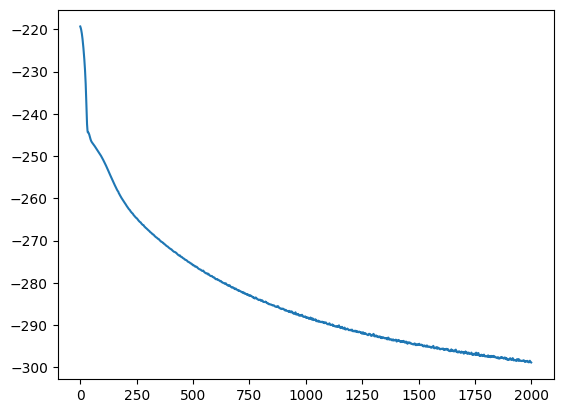

In [125]:
plt.plot(losses)

In [126]:
Y1 = scp_model.projection(opt_params['scp'], X)
# Y = jnp.clip(Y, -10000, 10000)
Y2 = nvp_model.apply(opt_params['nvp'], Y1, method=nvp_model.forward)[0]

(-15.0, 15.0)

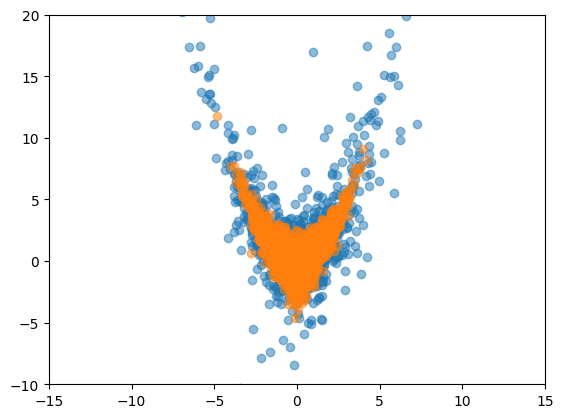

In [127]:
plt.scatter(exact_samples[:2000, 0], exact_samples[:2000, 1], alpha=0.5, label='Exact')
# plt.scatter(Y1[:, 0], Y1[:, 1], alpha=0.5)
plt.scatter(Y2[:, 0], Y2[:, 1], alpha=0.5)
plt.ylim(-10, 20)
plt.xlim(-15, 15)

In [128]:
exact_samples = target.sample(seed=jax.random.key(10), n=n_train)

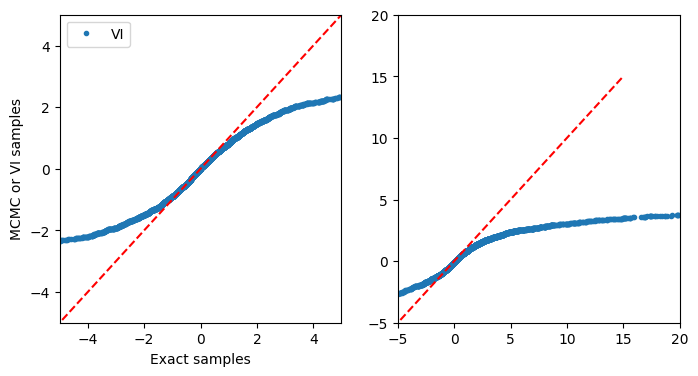

In [129]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    vi_sorted = jnp.sort(Y2[:, j])
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI')
    ax[i].set_xlim(jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99])))
    ax[i].set_ylim(jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99])))
    ax[i].plot([-15, 15], [-15, 15], 'r--')  # Reference line for y=x

ax[0].set_xlim(-5., 5)
ax[0].set_ylim(-5., 5)
ax[1].set_xlim(-5, 20)
ax[1].set_ylim(-5, 20)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

In [ ]:
def logp_transformed_by_nvp(x):
    y, logdet = nvp_model.apply(opt_params['nvp'], x, method=nvp_model.forward)
    logp = target.log_prob(y)
    return logp + logdet

logp_sphere = scp_model.transform_target(logp_transformed_by_nvp, opt_params['scp'])

nsample = 100_000
burnin = 500
x0 = uniform_sample_bright_side(d, latitude, jax.random.key(0), n=1)[0]
seed = 1
mcmc_samples_sphere, accepts = rwm_bright_side(logp_sphere, x0, latitude, key=jax.random.key(seed), nsample=nsample+burnin, stepsize=0.001)

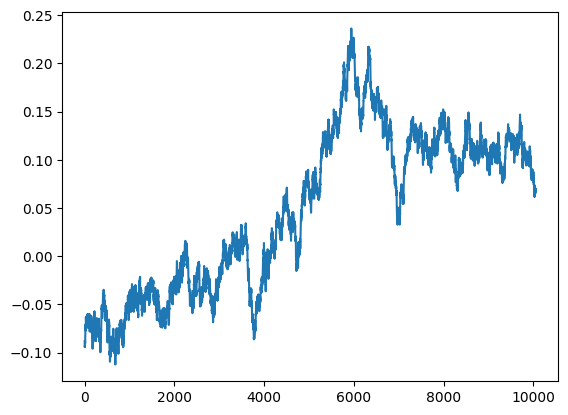

In [146]:
plt.plot(mcmc_samples_sphere[::10, 0])

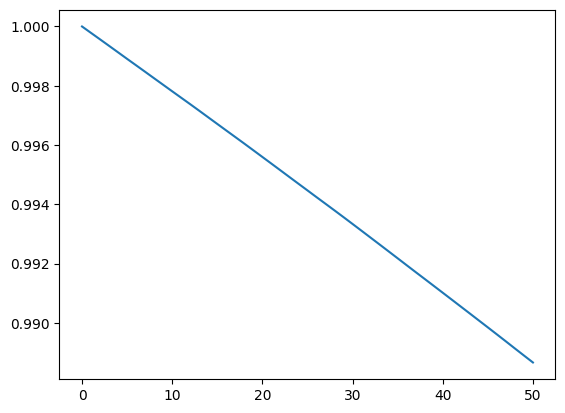

In [148]:
from statsmodels.tsa.stattools import acf
acf_vals = acf(mcmc_samples_sphere[:, 1], nlags=50, fft=True)  
plt.plot(acf_vals)

In [147]:
accepts.mean()

Array(0.7589552, dtype=float32)

(array([ 51.,  19., 170., 334., 344., 120.,  17., 142.,   0.,   8.]),
 array([-0.40092525, -0.31112406, -0.22132286, -0.13152167, -0.04172048,
         0.04808071,  0.1378819 ,  0.2276831 ,  0.31748429,  0.40728548,
         0.49708667]),
 <BarContainer object of 10 artists>)

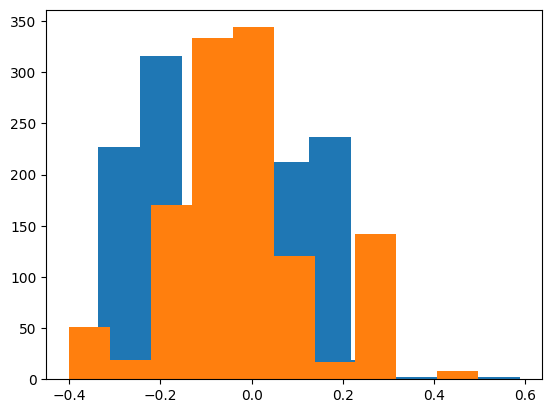

In [47]:
idx = mcmc_samples_sphere[:, -1] > 1.5
plt.hist((mcmc_samples_sphere[idx, 0]))
plt.hist((mcmc_samples_sphere[idx, 1]))

In [149]:
transformed_mcmc_samples = scp_model.projection(opt_params['scp'], mcmc_samples_sphere[burnin:])
transformed_mcmc_samples = nvp_model.apply(opt_params['nvp'], transformed_mcmc_samples, method=nvp_model.forward)[0]

(-10.0, 50.0)

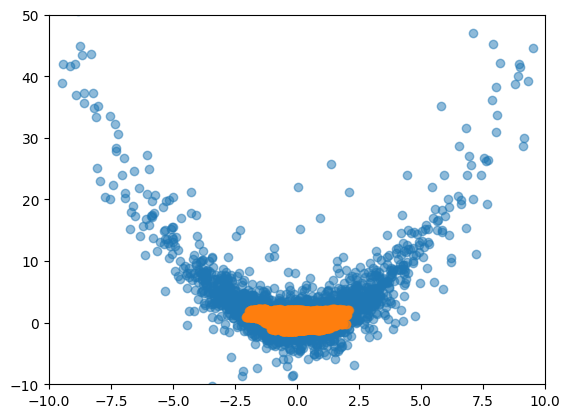

In [150]:
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5, label='Exact')
plt.scatter(transformed_mcmc_samples[:, 0], transformed_mcmc_samples[:, 1], alpha=0.5, label='MCMC')
plt.xlim(-10, 10)
plt.ylim(-10, 50)

In [50]:
exact_samples = target.sample(seed=jax.random.key(10), n=100_000)

In [51]:
jnp.quantile(exact_samples[:, 1], jnp.array([0.025, 0.975]))

Array([-2.5446687, 20.75769  ], dtype=float32)

In [52]:
ref_samples = uniform_sample_bright_side(d, latitude, jax.random.key(0), n=100_000)
vi_samples = scp_model.projection(opt_params['scp'], ref_samples)
# Y = jnp.clip(Y, -10000, 10000)
vi_samples = nvp_model.apply(opt_params['nvp'], vi_samples, method=nvp_model.forward)[0]

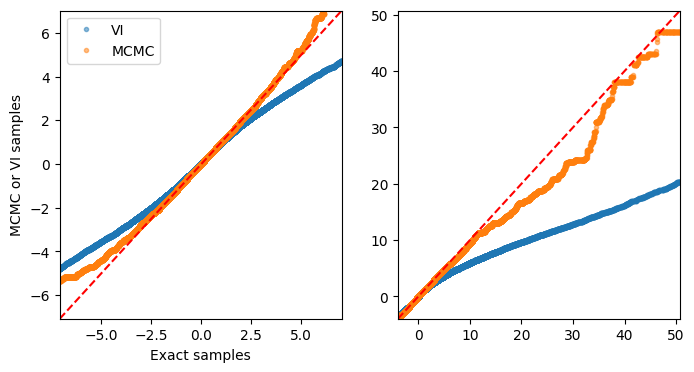

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    vi_sorted = jnp.sort(vi_samples[:, j])
    mcmc_sorted = jnp.sort(transformed_mcmc_samples[:, j])
    ax[i].plot(exact_sorted, vi_sorted, '.', label='VI', alpha=.5)
    ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC', alpha=.5)
    
    # qs = jnp.quantile(exact_samples[:, j], jnp.array([0.025, 0.975]))
    qs = jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99]))
    ax[i].set_xlim(qs)  
    ax[i].set_ylim(qs)
    ax[i].plot(qs, qs, 'r--')  # Reference line for y=x
# ax[1].set_xlim(-5, 50)
# ax[1].set_ylim(-5, 50)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

In [54]:
from scipy.stats import t

In [61]:
for a in [10, 20, 30, 40, 50]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 1] > a)), ', MCMC:', '{:.3}'.format(jnp.mean(transformed_mcmc_samples[:, 1] > a)))

CDF at x = 10
exact: 0.051 , MCMC: 0.0486
CDF at x = 20
exact: 0.026 , MCMC: 0.0203
CDF at x = 30
exact: 0.017 , MCMC: 0.0151
CDF at x = 40
exact: 0.013 , MCMC: 0.0122
CDF at x = 50
exact: 0.010 , MCMC: 0.00057


## NUTS

In [97]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

d = 200
df = 2
target = Banana_t(df=df, dim=d)

class Banana(dist.Distribution):
    arg_constraints = {'b': constraints.real}
    support = constraints.real_vector
    def __init__(self, d, validate_args=None):
        batch_shape = ()
        event_shape = (d,)
        super().__init__(batch_shape, event_shape, validate_args=validate_args)

    def log_prob(self, x):
        return target.log_prob(x)

def banana_model():
    numpyro.sample("z", Banana(d))

kernel = NUTS(banana_model, 
              adapt_mass_matrix=False, 
              init_strategy=numpyro.infer.init_to_value(values={'z': jnp.zeros(d) + 1000.}))
mcmc = MCMC(kernel, num_warmup=100, num_samples=100_000, num_chains=1)
mcmc.run(jax.random.key(4))
nuts_samples = mcmc.get_samples()['z']

sample: 100%|██████████| 100100/100100 [00:22<00:00, 4521.10it/s, 3 steps of size 7.36e+00. acc. prob=0.05]


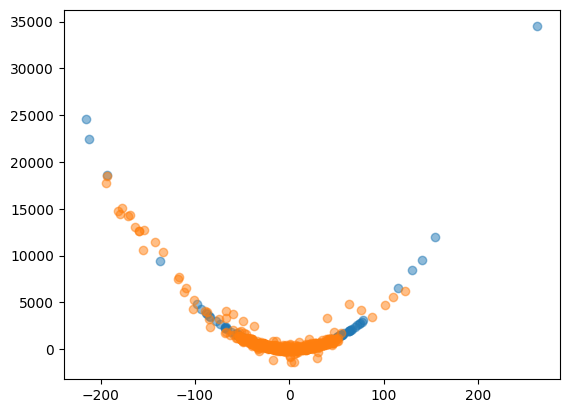

In [100]:
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5, label='Exact')
plt.scatter(nuts_samples[:, 0], nuts_samples[:, 1], alpha=0.5)
# plt.xlim(-10, 10)
# plt.ylim(-10, 50)

In [101]:
for a in [10, 20, 30, 40, 50]:
    print('CDF at x =', a)
    print('exact:', '{:.3f}'.format(jnp.mean(exact_samples[:, 1] > a)), ', MCMC:', '{:.3}'.format(jnp.mean(nuts_samples[:, 1] > a)))

CDF at x = 10
exact: 0.051 , MCMC: 0.552
CDF at x = 20
exact: 0.026 , MCMC: 0.335
CDF at x = 30
exact: 0.017 , MCMC: 0.233
CDF at x = 40
exact: 0.013 , MCMC: 0.193
CDF at x = 50
exact: 0.010 , MCMC: 0.153


In [66]:
exact_samples = target.sample(seed=jax.random.key(10), n=nuts_samples.shape[0])

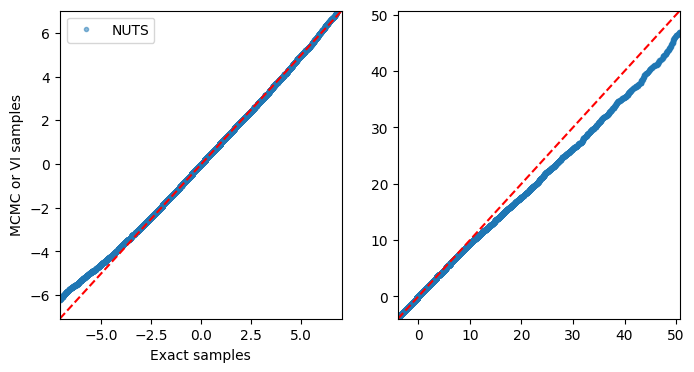

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for i, j in enumerate([0, 1]):
    exact_sorted = jnp.sort(exact_samples[:, j])
    # mcmc_sorted = jnp.sort(transformed_mcmc_samples[:, j])
    nuts_sorted = jnp.sort(nuts_samples[:, j])
    # ax[i].plot(exact_sorted, mcmc_sorted, '.', label='MCMC', alpha=.5)
    ax[i].plot(exact_sorted, nuts_sorted, '.', label='NUTS', alpha=.5)
    
    # qs = jnp.quantile(exact_samples[:, j], jnp.array([0.025, 0.975]))
    qs = jnp.quantile(exact_samples[:, j], jnp.array([0.01, 0.99]))
    ax[i].set_xlim(qs)  
    ax[i].set_ylim(qs)
    ax[i].plot(qs, qs, 'r--')  # Reference line for y=x
# ax[1].set_xlim(-5, 50)
# ax[1].set_ylim(-5, 50)
ax[0].set_xlabel('Exact samples')
ax[0].set_ylabel('MCMC or VI samples')
ax[0].legend()

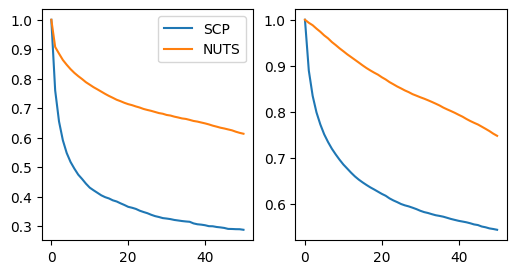

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for i in range(2):
    ax[i].plot(acf(transformed_mcmc_samples[:, i], nlags=50, fft=True), label='SCP')
    ax[i].plot(acf(nuts_samples[:, i], nlags=50, fft=True), label='NUTS')
ax[0].legend()

In [84]:
def RWM(logp_fn, x0, stepsize, nsample):
    def random_walk_step(carry, i):
        x, key = carry
        key, subkey = jax.random.split(key)
        x_new = x + jax.random.normal(subkey, shape=x.shape) * stepsize
        log_accept = logp_fn(x_new) - logp_fn(x)

        key, subkey = jax.random.split(key)
        u = jax.random.uniform(subkey)
        accept = (jnp.log(u) < log_accept) * 1.
        x = x * (1 - accept) + x_new * accept
        return (x, key), (x, accept)

    return jax.lax.scan(random_walk_step, (x0, key), jnp.arange(nsample))[1]

rwm_samples, rwm_accepts = RWM(target.log_prob, jnp.zeros(d), stepsize=0.2, nsample=100_000)

In [85]:
rwm_accepts.mean()

Array(0.6947, dtype=float32)

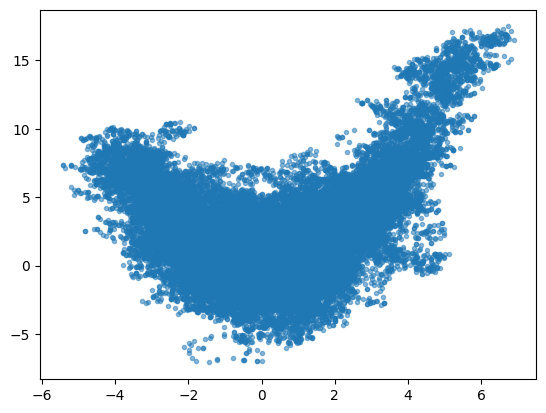

In [86]:
plt.plot(rwm_samples[:, 0], rwm_samples[:, 1], '.', alpha=0.5, label='RWM')